In [2]:
import math
import numpy as np

ref_genome_folder = 'Data/ref_genome/hg19'
exclude_chr = ['chrM', 'chrY']
resolution = 50000


# load ref genome length info
chr_length = dict()
with open(ref_genome_folder + '/hg19.len', 'r') as f:
    lines = f.read().splitlines()
    for line in lines:
        chr_name , len_ = line.split('\t')[:2]
        if chr_name in exclude_chr:
            continue
        chr_length[chr_name] = int(len_)
print('chr length : \n',chr_length)

# calculate bin number in each chr
chr_bin_number = dict()
for key in chr_length.keys():
    chr_bin_number[key] = math.floor(chr_length[key] / resolution) + 1
print('chr bin number : \n', chr_bin_number)

chr length : 
 {'chr1': 249250621, 'chr2': 243199373, 'chr3': 198022430, 'chr4': 191154276, 'chr5': 180915260, 'chr6': 171115067, 'chr7': 159138663, 'chr8': 146364022, 'chr9': 141213431, 'chr10': 135534747, 'chr11': 135006516, 'chr12': 133851895, 'chr13': 115169878, 'chr14': 107349540, 'chr15': 102531392, 'chr16': 90354753, 'chr17': 81195210, 'chr18': 78077248, 'chr19': 59128983, 'chr20': 63025520, 'chr21': 48129895, 'chr22': 51304566, 'chrX': 155270560}
chr bin number : 
 {'chr1': 4986, 'chr2': 4864, 'chr3': 3961, 'chr4': 3824, 'chr5': 3619, 'chr6': 3423, 'chr7': 3183, 'chr8': 2928, 'chr9': 2825, 'chr10': 2711, 'chr11': 2701, 'chr12': 2678, 'chr13': 2304, 'chr14': 2147, 'chr15': 2051, 'chr16': 1808, 'chr17': 1624, 'chr18': 1562, 'chr19': 1183, 'chr20': 1261, 'chr21': 963, 'chr22': 1027, 'chrX': 3106}


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

### load BICseq2

In [4]:
from load import load_seg_to_bin, load_seg_pair
BICseq_cnv_dict = load_seg_to_bin('CNV/WGS/K562/BICseq2/K562_WGS_CNV_lambda4.txt')
BICseq_seg = load_seg_pair('CNV/WGS/K562/BICseq2/K562_WGS_CNV_lambda4.txt')

In [5]:
# cause only display [-2,2]
for chr_ in BICseq_cnv_dict.keys():
    for i in range(len(BICseq_cnv_dict[chr_])):
        if BICseq_cnv_dict[chr_][i] >= 2:
            BICseq_cnv_dict[chr_][i] = 1.98
        elif BICseq_cnv_dict[chr_][i] <= -2:
            BICseq_cnv_dict[chr_][i] = -1.98
        
        if (BICseq_cnv_dict[chr_][i] < 0.2) and (BICseq_cnv_dict[chr_][i] > -0.2):
            BICseq_cnv_dict[chr_][i] = 0

### load Insulation score

In [6]:
IS_dict = dict()
for chr_ in chr_bin_number.keys():
    IS_dict[chr_] = np.zeros(chr_bin_number[chr_])

with open('Data/Insulation_score/GSE63525_K562_50k_IS_150kb.bed','r') as f:
    for line in f.readlines():
        line_split = line.strip().split('\t')
        chr_ , start_, is_score = line_split[0], int(line_split[1]), line_split[4]
        if (is_score == 'nan') or (is_score == 'inf') or (is_score == '-inf'):
            continue
        if (chr_ == 'Y') or (chr_ == 'MT'):
            continue
        bin_num = math.floor(start_ / resolution)
        is_score = float(is_score)
        IS_dict[f'chr{chr_}'][bin_num] = is_score

In [7]:
IS_boundary_dict = dict()
for chr_ in chr_bin_number.keys():
    IS_boundary_dict[chr_] = list()

with open('Data/Insulation_score/GSE63525_K562_50k_boundary_150kb.bed','r') as f:
    for line in f.readlines():
        line_split = line.strip().split()
        chr_ , start_ = line_split[0], int(line_split[1])
        if (chr_ == 'Y') or (chr_ == 'MT'):
            continue
        bin_num = math.floor(start_ / resolution)
        IS_boundary_dict[f'chr{chr_}'].append(bin_num)

### plot

Text(0, 0.5, 'Insulation Score')

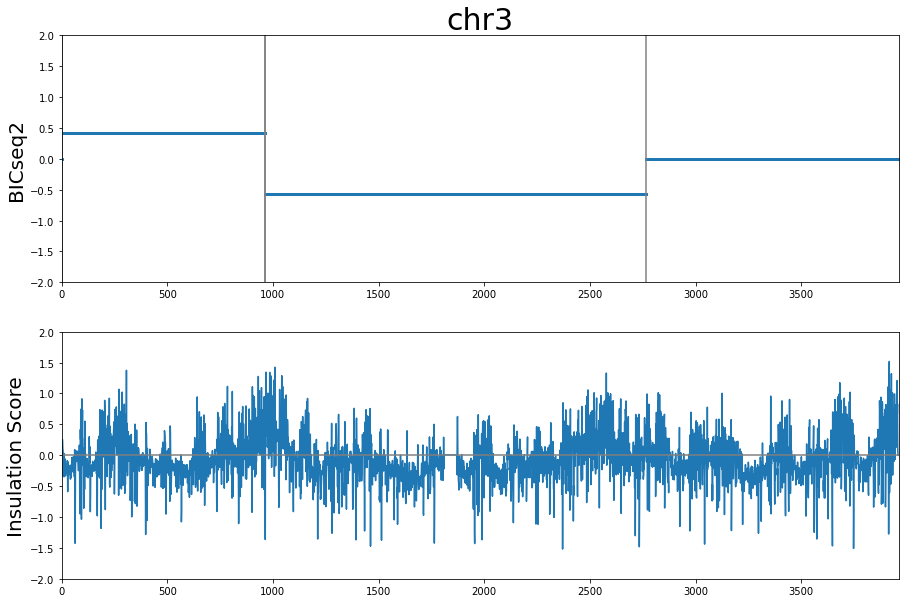

In [8]:
chrom = 'chr3'

fig, ax = plt.subplots(2,1, figsize=(15,10))
ax[0].scatter(range(0,len(BICseq_cnv_dict[chrom])), BICseq_cnv_dict[chrom], marker = ',', s=2)
ax[0].set_ylim([-2, 2])
ax[0].set_xlim([0, chr_bin_number[chrom]])
ax[0].set_ylabel('BICseq2', fontsize=20)
ax[0].set_title(chrom,fontdict = {'fontsize':30})
for seg in BICseq_seg[chrom]:
    ax[0].axvline(x=math.floor(int(seg[0])/resolution), color='grey')
    ax[0].axvline(x=math.floor(int(seg[1])/resolution), color='grey')

ax[1].plot(range(0,len(IS_dict[chrom])), IS_dict[chrom])
ax[1].axhline(y=0, color='grey')
ax[1].set_xlim([0, chr_bin_number[chrom]])
ax[1].set_ylim([-2, 2])
ax[1].set_ylabel('Insulation Score', fontsize=20)
# for bound in IS_boundary_dict[chrom]:
#     ax[1].axvline(x=bound, color='grey')